# MNIST Classification with Evaluation Metrics and Plots
This notebook demonstrates training a neural network on the MNIST dataset using TensorFlow/Keras.

We will:
- Load and preprocess the data
- Build and train a model
- Evaluate it using accuracy, precision, recall, and F1-score
- Plot training and validation accuracy/loss curves

In [ ]:
# 📦 Import all required libraries for MNIST classification and evaluation

import numpy as np  # Fundamental package for numerical operations, used for arrays and numerical functions

import matplotlib.pyplot as plt  # Library for plotting training/validation accuracy and loss curves

# Scikit-learn metrics for evaluating model performance
from sklearn.metrics import (
    accuracy_score,        # Measures overall correctness of predictions
    precision_score,       # Measures how many selected items are relevant (TP / (TP + FP))
    recall_score,          # Measures how many relevant items were selected (TP / (TP + FN))
    f1_score,              # Harmonic mean of precision and recall (2 * P * R / (P + R))
    classification_report  # Detailed breakdown of precision, recall, and F1-score for each class
)

import tensorflow as tf  # TensorFlow framework for deep learning and neural networks

# Keras modules inside TensorFlow
from tensorflow.keras.datasets import mnist         # Loads the MNIST handwritten digits dataset
from tensorflow.keras.models import Sequential       # Sequential model type (linear stack of layers)
from tensorflow.keras.layers import Dense, Flatten   # Dense = fully connected layer, Flatten = reshapes input
from tensorflow.keras.utils import to_categorical    # Converts integer labels to one-hot encoded format

In [ ]:
# Load MNIST dataset
# MNIST contains 60,000 training and 10,000 test images of handwritten digits (0-9)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Training data shape : (60000, 28, 28)
Training labels shape: (60000,)
Test data shape     : (10000, 28, 28)
Test labels shape   : (10000,)

Class distribution in training set:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


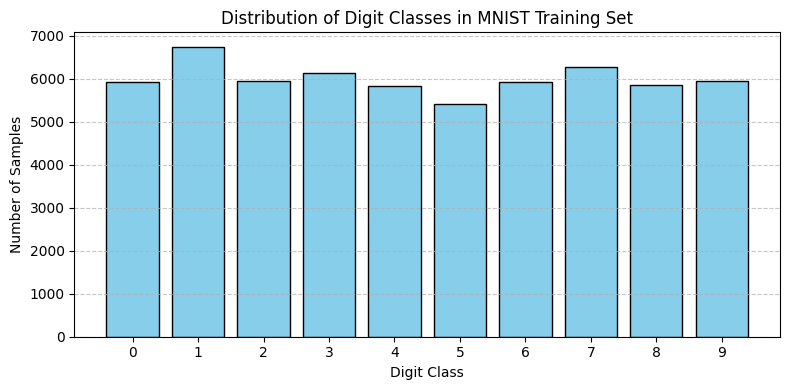

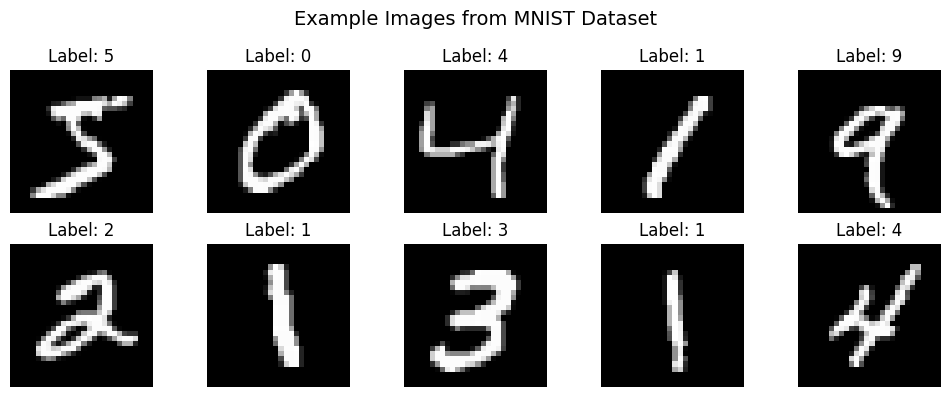

In [ ]:
# Import necessary libraries
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print dataset shapes
print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape     :", x_test.shape)
print("Test labels shape   :", y_test.shape)

# Display class distribution in training data
classes, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution in training set:")
for label, count in zip(classes, counts):
    print(f"Digit {label}: {count} samples")

# Plot bar chart of class distribution using matplotlib
plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title("Distribution of Digit Classes in MNIST Training Set")
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display sample images from the training set
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Example Images from MNIST Dataset", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Normalize pixel values to range [0, 1]
# Original images have pixel values between 0 and 255

# Why normalize?
# 1. Neural networks train faster and more stably when inputs are scaled to a small, consistent range.
# 2. Large input values (like 255) can cause numerical instability and slow convergence.
# 3. Normalization ensures all pixels have equal importance and helps activation functions work effectively.

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# One-hot encode the labels for use with categorical crossentropy loss

# Original labels are integers representing digits (0 to 9).
# For example, label '3' is represented simply as the integer 3.
# Neural networks require labels in a one-hot encoded format for multi-class classification.
# One-hot encoding converts each label into a vector where:
# - The index corresponding to the digit class is set to 1
# - All other indices are set to 0

# Example:
# Label 3  -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Label 7  -> [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

In [ ]:
from tensorflow.keras.layers import Conv2D,MaxPool2D

In [ ]:
conv2d_layer = Conv2D(32, (3, 3), activation='relu')

maxpool_layer = MaxPool2D(pool_size=(2, 2))

In [ ]:
# Build the neural network model using Keras Sequential API

model = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten the 28x28 pixel image into a 1D vector of length 784
                                    # This is required because Dense layers expect 1D input

    Dense(128, activation='relu'),  # First hidden layer with 128 neurons
                                    # Uses ReLU activation to introduce non-linearity, helping the model learn complex patterns

    Dense(64, activation='relu'),   # Second hidden layer with 64 neurons
                                    # Also uses ReLU activation for the same reasons

    Dense(32, activation='relu'),  # added third layer as per question

    Dense(10, activation='softmax') # Output layer with 10 neurons (one per digit class: 0-9)
                                    # Softmax activation converts outputs to probabilities that sum to 1,
                                    # allowing the model to predict the most likely digit class
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
# - Optimizer: Adam (adaptive learning rate)
# - Loss: categorical crossentropy (used for multi-class classification)
# - Metrics: accuracy
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model and store the training history
# - validation_split=0.1 reserves 10% of training data for validation
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8560 - loss: 0.4781 - val_accuracy: 0.9665 - val_loss: 0.1134
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9644 - loss: 0.1187 - val_accuracy: 0.9733 - val_loss: 0.0925
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9752 - loss: 0.0820 - val_accuracy: 0.9732 - val_loss: 0.0965
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9812 - loss: 0.0617 - val_accuracy: 0.9775 - val_loss: 0.0856
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9840 - loss: 0.0485 - val_accuracy: 0.9798 - val_loss: 0.0783


output for batchsize=32, epoch=5

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8527 - loss: 0.4922 - val_accuracy: 0.9633 - val_loss: 0.1270
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9638 - loss: 0.1181 - val_accuracy: 0.9692 - val_loss: 0.1035
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9773 - loss: 0.0741 - val_accuracy: 0.9772 - val_loss: 0.0794
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9821 - loss: 0.0549 - val_accuracy: 0.9778 - val_loss: 0.0804
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9870 - loss: 0.0423 - val_accuracy: 0.9737 - val_loss: 0.0885


In [ ]:
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=62, validation_split=0.1)

Epoch 1/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9906 - loss: 0.0290 - val_accuracy: 0.9778 - val_loss: 0.0798
Epoch 2/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9944 - loss: 0.0187 - val_accuracy: 0.9790 - val_loss: 0.0851
Epoch 3/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9802 - val_loss: 0.0820
Epoch 4/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9945 - loss: 0.0160 - val_accuracy: 0.9813 - val_loss: 0.0938
Epoch 5/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9943 - loss: 0.0174 - val_accuracy: 0.9795 - val_loss: 0.0920


output for batchsize=64, epoch=5

Epoch 1/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 0.9782 - val_loss: 0.0815

Epoch 2/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9952 - loss: 0.0179 - val_accuracy: 0.9803 - val_loss: 0.0697

Epoch 3/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9802 - val_loss: 0.0831

Epoch 4/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9942 - loss: 0.0168 - val_accuracy: 0.9830 - val_loss: 0.0792

Epoch 5/5
871/871 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9815 - val_loss: 0.0774

In [ ]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print(f"\nTest Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9747 - loss: 0.0989

Test Accuracy: 0.9773


* Before 3rd layer :
 test accuracy: 0.9753
*  After 3rd layer:
 test accuracy: 0.9753 (no changes)



In [ ]:
# Predict class probabilities for the test set
y_pred_probs = model.predict(x_test)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Compute and print evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Accuracy : 0.9773
Precision: 0.9774
Recall   : 0.9773
F1-score : 0.9773

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.98      0.97      0.98       892
           6       0.97      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Before 3rd layer values :
Accuracy : 0.9753
Precision: 0.9754
Recall   : 0.9753
F1-score : 0.9753

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.95      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.97      0.98     10000
weighted avg       0.98      0.98      0.98     10000

<To check after 3rd layer>



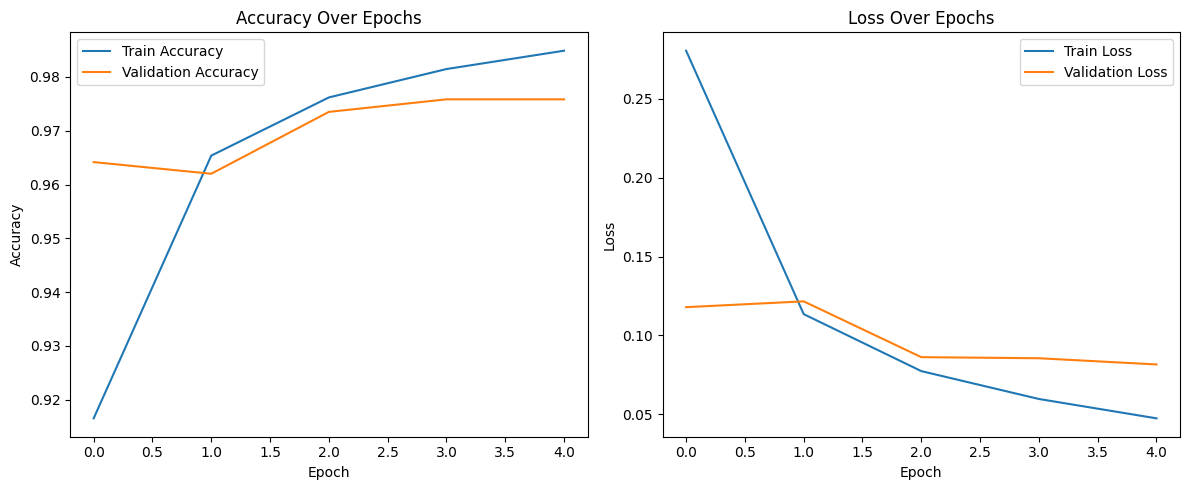

In [ ]:
# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Image before adding 3rd layer for accuracy over epochs and loss over epochs

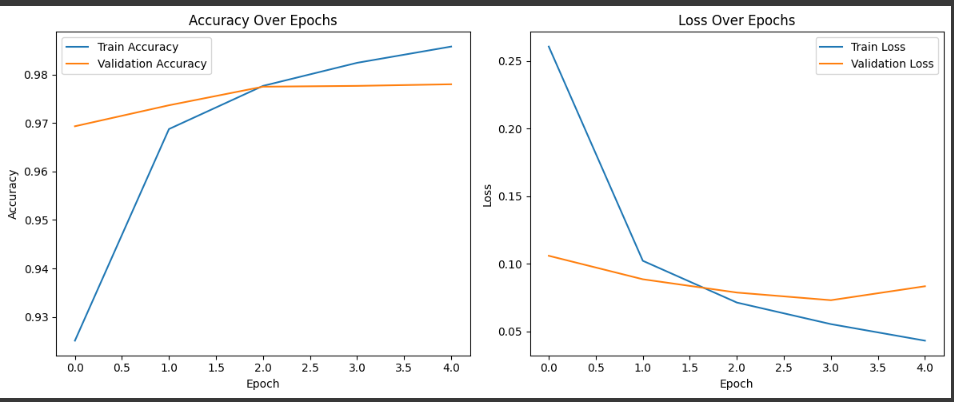

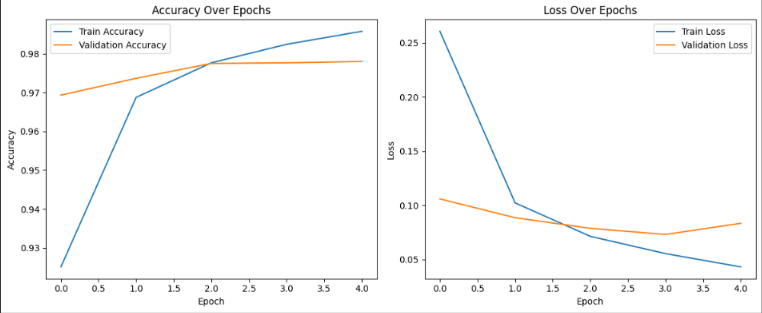